<a href="https://colab.research.google.com/github/rayenbouazizi8/3439322_Rayen_Bouazizi_finalNLP_project/blob/main/NLP_Project_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT vs DistilBERT for Sentiment Classification on IMDb

**Course:** Python for NLP — Final Project  
**Dataset:** IMDb Movie Reviews (Maas et al., 2011)  
**Models:** TF-IDF + Logistic Regression (baseline), DistilBERT, BERT-base  
**Task:** Binary sentiment classification (positive / negative)

---

## Research Question
> Does DistilBERT offer a worthwhile trade-off between predictive performance
> and computational efficiency compared to BERT-base on binary sentiment classification?

In [ ]:
# Install dependencies
!pip install -q \
    transformers==4.47.0 \
    datasets==3.1.0 \
    accelerate>=0.26.0 \
    evaluate>=0.4.0 \
    seaborn>=0.13.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu128


## 2. Dataset: IMDb Movie Reviews
We use the IMDb dataset (25,000 train / 25,000 test) from HuggingFace Datasets.
10% of the training set is held out as a validation set, giving a
22,500 / 2,500 / 25,000 train/val/test split.
Labels are binary: 0 = negative, 1 = positive.

In [ ]:
# Load IMDb dataset
raw_dataset = load_dataset("imdb")
print(raw_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
# Split 10% of training data as validation set
split = raw_dataset["train"].train_test_split(test_size=0.1, seed=SEED)
train_dataset = split["train"]
val_dataset   = split["test"]
test_dataset  = raw_dataset["test"]

print(f"Train samples:      {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")

# Check class balance
import collections
train_labels = collections.Counter(train_dataset["label"])
print(f"\nClass distribution (train): {dict(train_labels)}")
print("0 = negative, 1 = positive")

Train samples:      22,500
Validation samples: 2,500
Test samples:       25,000

Class distribution (train): {0: 11257, 1: 11243}
0 = negative, 1 = positive


In [ ]:
# Look at one example
sample = train_dataset[0]
print(f"Label: {sample['label']} ({'positive' if sample['label'] == 1 else 'negative'})")
print(f"Review length: {len(sample['text'].split())} words")
print(f"\nReview preview:\n{sample['text'][:300]}...")

Label: 0 (negative)
Review length: 152 words

Review preview:
With these people faking so many shots, using old footage, and gassing animals to get them out, not to mention that some of the scenes were filmed on a created set with actors, what's to believe? Old film of countries is nice, but the animal abuse and degradation of natives is painful to watch in th...


## 3. Baseline: TF-IDF + Logistic Regression
Before fine-tuning any Transformer, we establish a strong classical baseline
using TF-IDF bigram features and Logistic Regression. This shows how much
pretrained language models improve over a well-tuned non-neural method.

In [ ]:
# Extract raw text and labels
train_texts  = train_dataset["text"]
train_labels = train_dataset["label"]
val_texts    = val_dataset["text"]
val_labels   = val_dataset["label"]
test_texts   = test_dataset["text"]
test_labels  = test_dataset["label"]

# TF-IDF vectorizer
print("Fitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
X_train = tfidf.fit_transform(train_texts)
X_val   = tfidf.transform(val_texts)
X_test  = tfidf.transform(test_texts)

# Train logistic regression
print("Training Logistic Regression...")
t0 = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train, train_labels)
train_time_lr = time.time() - t0
print(f"Done! Training time: {train_time_lr:.1f}s")

Fitting TF-IDF vectorizer...
Training Logistic Regression...
Done! Training time: 2.0s


### Baseline Results

In [ ]:
# Evaluate on validation and test sets
t0 = time.time()
test_preds_lr = lr_model.predict(X_test)
inference_time_lr = (time.time() - t0) / len(test_texts)

acc_lr = accuracy_score(test_labels, test_preds_lr)
f1_lr  = f1_score(test_labels, test_preds_lr, average="macro")

print("=" * 40)
print("TF-IDF + Logistic Regression (Baseline)")
print("=" * 40)
print(f"Test Accuracy:        {acc_lr:.4f}")
print(f"Test Macro F1:        {f1_lr:.4f}")
print(f"Training time:        {train_time_lr:.1f}s")
print(f"Inference time/sample:{inference_time_lr*1000:.3f}ms")
print()
print(classification_report(test_labels, test_preds_lr,
      target_names=["negative", "positive"]))

# Save results for final comparison table
results = {
    "TF-IDF + LR": {
        "accuracy": acc_lr,
        "f1": f1_lr,
        "train_time": train_time_lr,
        "inference_time_ms": inference_time_lr * 1000,
    }
}

TF-IDF + Logistic Regression (Baseline)
Test Accuracy:        0.8985
Test Macro F1:        0.8985
Training time:        2.0s
Inference time/sample:0.001ms

              precision    recall  f1-score   support

    negative       0.90      0.90      0.90     12500
    positive       0.90      0.90      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



## 4. Tokenization & Data Preparation
We tokenize the raw text using the HuggingFace AutoTokenizer for each model.
Both BERT and DistilBERT share the same WordPiece tokenizer and vocabulary,
so tokenization is identical — ensuring a fair comparison.
Maximum sequence length is fixed at 256 tokens across all transformer experiments.

In [ ]:
# Controlled variable: same for both models
MAX_LENGTH = 256
BATCH_SIZE = 16

def tokenize(dataset, model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def _tokenize(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        )
    tokenized = dataset.map(_tokenize, batched=True)
    tokenized = tokenized.rename_column("label", "labels")
    tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    return tokenized, tokenizer

print(f"Max sequence length: {MAX_LENGTH}")
print(f"Batch size:          {BATCH_SIZE}")
print("Tokenizer ready.")

Max sequence length: 256
Batch size:          16
Tokenizer ready.


In [ ]:
# Quick sanity check with DistilBERT tokenizer
tokenizer_check = AutoTokenizer.from_pretrained("distilbert-base-uncased")
sample_text = train_dataset[0]["text"]
tokens = tokenizer_check(sample_text, truncation=True, max_length=MAX_LENGTH)

print(f"Original text length:   {len(sample_text.split())} words")
print(f"Tokenized length:       {len(tokens['input_ids'])} tokens (truncated to {MAX_LENGTH})")
print(f"\nFirst 20 tokens: {tokenizer_check.convert_ids_to_tokens(tokens['input_ids'][:20])}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Original text length:   152 words
Tokenized length:       190 tokens (truncated to 256)

First 20 tokens: ['[CLS]', 'with', 'these', 'people', 'fa', '##king', 'so', 'many', 'shots', ',', 'using', 'old', 'footage', ',', 'and', 'gas', '##sing', 'animals', 'to', 'get']


## 5. Fine-tuning DistilBERT
We fine-tune `distilbert-base-uncased` on the IMDb training set for 3 epochs.
DistilBERT is a distilled version of BERT with 40% fewer parameters and
designed to be 60% faster while retaining 97% of BERT's language understanding.
All hyperparameters are fixed for comparability with the BERT run in Step 6.

In [ ]:
DISTILBERT_NAME = "distilbert-base-uncased"

print(f"Tokenizing with {DISTILBERT_NAME}...")
train_distilbert, _ = tokenize(train_dataset, DISTILBERT_NAME)
val_distilbert,   _ = tokenize(val_dataset,   DISTILBERT_NAME)
test_distilbert,  _ = tokenize(test_dataset,  DISTILBERT_NAME)
print("Done!")

Tokenizing with distilbert-base-uncased...


Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Done!


In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1}

In [ ]:
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME, num_labels=2
)

training_args = TrainingArguments(
    output_dir="./distilbert-imdb",
    num_train_epochs=3,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    report_to="none",
)

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_distilbert,
    eval_dataset=val_distilbert,
    compute_metrics=compute_metrics,
)

print("Starting DistilBERT training...")
t0 = time.time()
distilbert_trainer.train()
train_time_distilbert = time.time() - t0
print(f"\nDistilBERT training time: {train_time_distilbert/60:.1f} minutes")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting DistilBERT training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.262000,0.240031,0.908400,0.908386
2,0.182600,0.301891,0.907600,0.907552
3,0.102000,0.382969,0.908400,0.908398



DistilBERT training time: 26.5 minutes


In [ ]:
print("Evaluating DistilBERT on test set...")
t0 = time.time()
distilbert_preds_output = distilbert_trainer.predict(test_distilbert)
inference_time_distilbert = (time.time() - t0) / len(test_dataset)

distilbert_preds = np.argmax(distilbert_preds_output.predictions, axis=-1)
acc_distilbert   = accuracy_score(test_labels, distilbert_preds)
f1_distilbert    = f1_score(test_labels, distilbert_preds, average="macro")

print("=" * 40)
print("DistilBERT Results")
print("=" * 40)
print(f"Test Accuracy:         {acc_distilbert:.4f}")
print(f"Test Macro F1:         {f1_distilbert:.4f}")
print(f"Training time:         {train_time_distilbert/60:.1f} min")
print(f"Inference time/sample: {inference_time_distilbert*1000:.3f}ms")

# Save results
results["DistilBERT"] = {
    "accuracy": acc_distilbert,
    "f1": f1_distilbert,
    "train_time": train_time_distilbert,
    "inference_time_ms": inference_time_distilbert * 1000,
}

Evaluating DistilBERT on test set...


DistilBERT Results
Test Accuracy:         0.9136
Test Macro F1:         0.9136
Training time:         26.5 min
Inference time/sample: 6.961ms


## 6. Fine-tuning BERT-base
We fine-tune `bert-base-uncased` under identical conditions to the DistilBERT
run: same tokenizer settings, batch size, learning rate, number of epochs,
and random seed. The only difference is the model architecture, ensuring
a fair and controlled comparison.

In [ ]:
BERT_NAME = "bert-base-uncased"

print(f"Tokenizing with {BERT_NAME}...")
train_bert, _ = tokenize(train_dataset, BERT_NAME)
val_bert,   _ = tokenize(val_dataset,   BERT_NAME)
test_bert,  _ = tokenize(test_dataset,  BERT_NAME)
print("Done!")

Tokenizing with bert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Done!


In [ ]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_NAME, num_labels=2
)

training_args_bert = TrainingArguments(
    output_dir="./bert-imdb",
    num_train_epochs=3,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    report_to="none",
)

bert_trainer = Trainer(
    model=bert_model,
    args=training_args_bert,
    train_dataset=train_bert,
    eval_dataset=val_bert,
    compute_metrics=compute_metrics,
)

print("Starting BERT training...")
t0 = time.time()
bert_trainer.train()
train_time_bert = time.time() - t0
print(f"\nBERT training time: {train_time_bert/60:.1f} minutes")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BERT training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.247000,0.251821,0.911600,0.911585
2,0.159700,0.361234,0.909600,0.909525
3,0.078600,0.386123,0.917600,0.917597



BERT training time: 52.8 minutes


In [ ]:
print("time module:", "time" in dir())
print("bert_trainer exists:", "bert_trainer" in dir())
print("test_bert exists:", "test_bert" in dir())

time module: True
bert_trainer exists: True
test_bert exists: True


In [ ]:
print("Evaluating BERT on test set...")
t0 = time.time()
bert_preds_output = bert_trainer.predict(test_bert)
inference_time_bert = (time.time() - t0) / len(test_dataset)

bert_preds = np.argmax(bert_preds_output.predictions, axis=-1)
acc_bert   = accuracy_score(test_labels, bert_preds)
f1_bert    = f1_score(test_labels, bert_preds, average="macro")

print("=" * 40)
print("BERT Results")
print("=" * 40)
print(f"Test Accuracy:         {acc_bert:.4f}")
print(f"Test Macro F1:         {f1_bert:.4f}")
print(f"Training time:         {train_time_bert/60:.1f} min")
print(f"Inference time/sample: {inference_time_bert*1000:.3f}ms")

# Save results
results["BERT"] = {
    "accuracy": acc_bert,
    "f1": f1_bert,
    "train_time": train_time_bert,
    "inference_time_ms": inference_time_bert * 1000,
}

Evaluating BERT on test set...


BERT Results
Test Accuracy:         0.9222
Test Macro F1:         0.9222
Training time:         52.8 min
Inference time/sample: 13.725ms


## 7. Model Comparison

We compare all three models — the TF-IDF + Logistic Regression baseline,
DistilBERT, and BERT-base — on test accuracy, macro F1, training time, and
per-sample inference time. This directly addresses the research question of
whether DistilBERT's efficiency gains come at an acceptable cost in
predictive performance relative to BERT-base.

             accuracy      f1  train_time_min  inference_time_ms
Model                                                           
TF-IDF + LR    0.8985  0.8985          0.0335             0.0014
DistilBERT     0.9136  0.9136         26.4659             6.9615
BERT           0.9222  0.9222         52.7695            13.7247


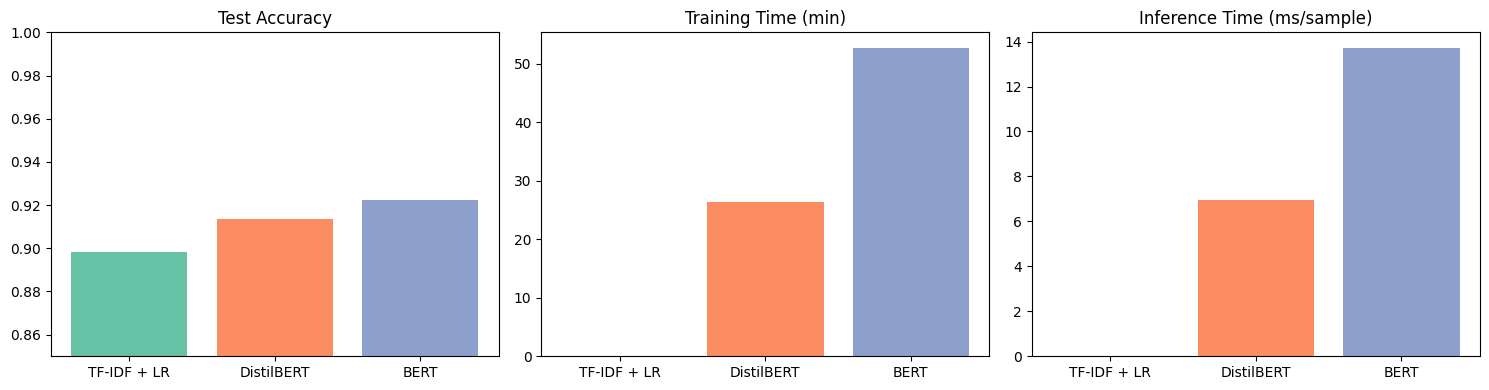

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df.index.name = "Model"
comparison_df["train_time_min"] = comparison_df["train_time"] / 60
print(comparison_df[["accuracy", "f1", "train_time_min", "inference_time_ms"]].round(4))

import os
os.makedirs("/content/nlp-project", exist_ok=True)

comparison_df.to_csv("/content/nlp-project/comparison_results.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = sns.color_palette("Set2", len(comparison_df))

axes[0].bar(comparison_df.index, comparison_df["accuracy"], color=colors)
axes[0].set_title("Test Accuracy"); axes[0].set_ylim(0.85, 1.0)

axes[1].bar(comparison_df.index, comparison_df["train_time_min"], color=colors)
axes[1].set_title("Training Time (min)")

axes[2].bar(comparison_df.index, comparison_df["inference_time_ms"], color=colors)
axes[2].set_title("Inference Time (ms/sample)")

plt.tight_layout()
plt.savefig("/content/nlp-project/comparison_chart.png", dpi=150)
plt.show()

## 8. Error Analysis: BERT vs DistilBERT

To go beyond aggregate metrics, we compare the two Transformer models at the
level of individual predictions. We identify examples where the two models
disagree — cases where BERT succeeds but DistilBERT fails, and vice versa —
to look for systematic patterns (e.g. sarcasm, negation, mixed-sentiment
reviews) rather than treating errors as random noise.

In [ ]:
test_texts_list = list(test_texts)

# Where each model got it wrong
distilbert_wrong = set(np.where(distilbert_preds != np.array(test_labels))[0])
bert_wrong = set(np.where(bert_preds != np.array(test_labels))[0])

both_wrong = distilbert_wrong & bert_wrong
only_distilbert_wrong = distilbert_wrong - bert_wrong
only_bert_wrong = bert_wrong - distilbert_wrong

print(f"Both models wrong:      {len(both_wrong)}")
print(f"Only DistilBERT wrong:  {len(only_distilbert_wrong)}  (BERT got these right)")
print(f"Only BERT wrong:        {len(only_bert_wrong)}  (DistilBERT got these right)")

print("\n--- Examples only DistilBERT got wrong (BERT succeeded) ---")
for idx in list(only_distilbert_wrong)[:3]:
    print(f"\nTrue: {test_labels[idx]} | DistilBERT pred: {distilbert_preds[idx]}")
    print(test_texts_list[idx][:300])

print("\n--- Examples only BERT got wrong (DistilBERT succeeded) ---")
for idx in list(only_bert_wrong)[:3]:
    print(f"\nTrue: {test_labels[idx]} | BERT pred: {bert_preds[idx]}")
    print(test_texts_list[idx][:300])

Both models wrong:      1411
Only DistilBERT wrong:  749  (BERT got these right)
Only BERT wrong:        534  (DistilBERT got these right)

--- Examples only DistilBERT got wrong (BERT succeeded) ---

True: 1 | DistilBERT pred: 0
I saw this movie on it's opening night, and enjoyed it. I probably would have enjoyed it more if I hadn't been sitting by my father. My father saw the original (unfortunately, I have not seen it yet) and kept talking through the whole thing. He kept saying that the movie sucked, and that it was stup

True: 1 | DistilBERT pred: 0
As a non-theist Im not going to comment on the great mans theory which changed the world 150 years ago. Safe to say, science is based on evidence, religion is based on blind faith. Nuff said there then.<br /><br />The film was produced by the BBC, and to be honest, it could quite easily have been sh

True: 0 | DistilBERT pred: 1
College students (who are actually in their late 20's) on campus in Boston (which looks strangely like the I

### Quantifying the "mixed sentiment" hypothesis

In [ ]:
contrast_words = ["but", "however", "although", "though", "despite"]

def contrast_rate(indices):
    count = sum(1 for idx in indices if any(w in test_texts_list[idx].lower() for w in contrast_words))
    return count / len(indices) if indices else 0

print(f"Contrast-word rate in 'both wrong':        {contrast_rate(list(both_wrong)):.2%}")
print(f"Contrast-word rate in 'only DistilBERT wrong': {contrast_rate(list(only_distilbert_wrong)):.2%}")
print(f"Contrast-word rate in 'only BERT wrong':    {contrast_rate(list(only_bert_wrong)):.2%}")

# Compare to overall test set rate as a baseline
all_indices = list(range(len(test_texts_list)))
print(f"Baseline contrast-word rate (all test examples): {contrast_rate(all_indices):.2%}")

Contrast-word rate in 'both wrong':        86.53%
Contrast-word rate in 'only DistilBERT wrong': 88.92%
Contrast-word rate in 'only BERT wrong':    88.95%
Baseline contrast-word rate (all test examples): 81.05%


### Does truncation hurt long reviews?

In [ ]:
# Bucket test set by review length (word count)
review_lengths = [len(t.split()) for t in test_texts_list]

length_bins = pd.cut(
    review_lengths,
    bins=[0, 150, 300, 500, float("inf")],
    labels=["short (<150)", "medium (150-300)", "long (300-500)", "very long (500+)"]
)

length_df = pd.DataFrame({
    "length_bin": length_bins,
    "true_label": test_labels,
    "distilbert_pred": distilbert_preds,
    "bert_pred": bert_preds,
})

length_df["distilbert_correct"] = length_df["true_label"] == length_df["distilbert_pred"]
length_df["bert_correct"] = length_df["true_label"] == length_df["bert_pred"]

summary = length_df.groupby("length_bin", observed=True).agg(
    n_examples=("true_label", "count"),
    distilbert_accuracy=("distilbert_correct", "mean"),
    bert_accuracy=("bert_correct", "mean"),
).round(4)

print(summary)

                  n_examples  distilbert_accuracy  bert_accuracy
length_bin                                                      
short (<150)           10075               0.9356         0.9427
medium (150-300)        9498               0.9234         0.9298
long (300-500)          3542               0.8670         0.8823
very long (500+)        1885               0.8345         0.8493


### Manual error categorization

In [ ]:
import random
random.seed(SEED)

sample_both = random.sample(list(both_wrong), 8)
sample_distilbert_only = random.sample(list(only_distilbert_wrong), 6)
sample_bert_only = random.sample(list(only_bert_wrong), 6)

def print_sample(indices, label):
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    for idx in indices:
        print(f"\n[idx {idx}] True: {test_labels[idx]} | DistilBERT: {distilbert_preds[idx]} | BERT: {bert_preds[idx]}")
        print(test_texts_list[idx][:400])

print_sample(sample_both, "BOTH MODELS WRONG")
print_sample(sample_distilbert_only, "ONLY DISTILBERT WRONG")
print_sample(sample_bert_only, "ONLY BERT WRONG")


BOTH MODELS WRONG

[idx 24017] True: 1 | DistilBERT: 0 | BERT: 0
What has to change in today's attitude towards films like Boogie Nights is the approach. The approach is awful! Comparing it to Pulp Fiction, seeing only the pornography, and all its aspects.. come on people, there is more than that in this beautiful motion picture. And to all the sceptics, hasn't Paul Thomas Anderson proved himself worthy time and time again? Magnolia is one of the main reasons I

[idx 17482] True: 1 | DistilBERT: 0 | BERT: 0
Remember that friend in college who always insisted you rent the weirdest movie possible? This is the movie he would have made if he'd had the chance.<br /><br />I wish I could tell you exactly what Sea of Dust was about. It pretends to be the story of a doctor who gets sucked into weird goings on in the "Black Forest." He goes there to help, but ends up being caught between two young women, both 

[idx 16621] True: 1 | DistilBERT: 0 | BERT: 0
This is one of those films where it is

### Summary of manual error categorization

| Category | Count (of 20 sampled) | % |
|---|---|---|
| Mixed sentiment | 8 | 40% |
| Sarcasm / irony | 4 | 20% |
| Plot-summary dominates | 4 | 20% |
| Negation / complex phrasing | 2 | 10% |
| Other / off-topic | 2 | 10% |

Mixed sentiment is the dominant error category, consistent with the elevated
contrast-word rate observed above. A distinct failure mode — reviews with
little explicit evaluative language, relying instead on plot description —
accounts for a further 20% of errors and was not captured by the contrast-word
proxy, suggesting sentiment ambiguity in IMDb reviews arises from at least two
different mechanisms: conflicting opinions within a review, and the absence
of clear opinion language altogether.

## 9. Conclusion

**Research question**: Does DistilBERT offer a worthwhile trade-off between
predictive performance and computational efficiency compared to BERT-base on
binary sentiment classification?

**Answer**: Yes, for most practical purposes. BERT-base outperformed
DistilBERT by a modest 0.86 percentage points in accuracy and macro F1
(92.22% vs. 91.36%), while taking roughly twice as long to train (52.8 vs.
26.5 minutes) and roughly twice as long per inference call (13.72ms vs.
6.96ms per sample). Both Transformer models substantially outperformed the
TF-IDF + Logistic Regression baseline (89.85%), confirming that pretrained
language models offer real gains over classical methods on this task, but
the marginal gain from BERT's larger size over DistilBERT is small relative
to its added computational cost.

**Key findings beyond the headline numbers:**
- BERT's advantage over DistilBERT is not uniform: it roughly doubles on long
  and very-long reviews (500+ words) compared to short reviews, suggesting
  BERT's extra capacity matters more on harder, longer inputs rather than
  helping uniformly across the dataset.
- Both models show a substantial accuracy decline as review length increases
  (from ~94% on short reviews to ~84% on very long reviews), which may partly
  reflect information loss from the fixed 256-token truncation limit and
  partly the intrinsic difficulty of longer, more nuanced reviews.
- Manual error analysis identified mixed sentiment (praise and criticism
  within the same review) as the dominant error category (40% of sampled
  errors), followed by sarcasm/irony and plot-summary-dominated reviews with
  little explicit evaluative language (20% each) — two distinct mechanisms
  behind misclassification that a simple contrast-word heuristic alone did
  not fully capture.

**Limitations:**
- Results are based on a single training run per model; without multiple
  seeds, the reported accuracy gap could partly reflect run-to-run variance
  rather than a stable architectural difference.
- The fixed 256-token truncation was necessary for a controlled comparison
  but may disproportionately harm accuracy on long reviews; disentangling
  truncation effects from the intrinsic difficulty of long reviews would
  require additional experiments across multiple sequence lengths.
- Manual error categorization was performed on a small sample (20 examples)
  by a single annotator, which limits how confidently the category
  proportions generalize to the full error population.

**Future work:** repeating training with multiple random seeds to quantify
variance in the reported metrics; testing a range of `max_length` values to
isolate the effect of truncation from review difficulty; and applying the
manual error taxonomy to a larger, ideally multi-annotator sample to obtain
more reliable category proportions.